In [1]:
import Pkg
Pkg.activate("/home/matteo/Projects/OU_inference/")

  Activating project at `~/Projects/OU_inference`


In [2]:
using Revise

In [3]:
using DiffusionEvolution, LinearAlgebra, PyPlot

Precompiling DiffusionEvolution
  ✓ DiffusionEvolution
  1 dependency successfully precompiled in 6 seconds. 178 already precompiled.
[ Info: Precompiling DiffusionEvolution [fede2d61-eba6-4945-aa96-3bfe712f026f]
[ Info: Precompiling PyPlot [d330b81b-6aea-500a-939a-2ce795aea3ee]
Precompiling ZygoteColorsExt
  ✓ Zygote → ZygoteColorsExt
  1 dependency successfully precompiled in 30 seconds. 78 already precompiled.
[ Info: Precompiling ZygoteColorsExt [e68c091a-8ea5-5ca7-be4f-380657d4ad79]
┌ Warning: Module Zygote with build ID fafbfcfd-3a32-e9db-0000-4c73432f73d5 is missing from the cache.
│ This may mean Zygote [e88e6eb3-aa80-5325-afca-941959d7151f] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:1948
[ Info: Skipping precompilation since __precompile__(false). Importing ZygoteColorsExt [e68c091a-8ea5-5ca7-be4f-380657d4ad79].


In [4]:
const de = DiffusionEvolution

DiffusionEvolution

In [5]:
import PyPlot.subplots
subplots(x,y,d) = subplots(x, y, figsize=(y*d, x*d))

subplots (generic function with 2 methods)

In [6]:
d = 10
nsamples = 1000
T = 50

50

In [7]:
β = 0.1

0.1

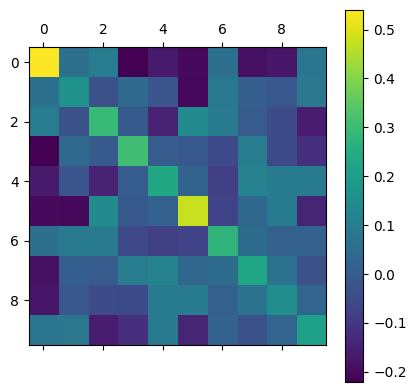

PyObject <matplotlib.colorbar.Colorbar object at 0x75ace85b9fc0>

In [8]:
m = randn(d,d)
J = (m * m') * (β/sqrt(d))
matshow(J)
colorbar()

In [9]:
θ = randn(d)
θ ./= norm(θ)
θ .*= 10*d

10-element Vector{Float64}:
  29.33010441228543
  37.162538680406925
 -21.930194756094988
  60.676158734163145
 -37.28071424543592
  14.431665861717462
   7.2872797160391825
  38.63202796749907
 -10.608858470275795
 -18.437745806909188

In [125]:
γ = 0.01

0.01

In [126]:
x_sim = simulate_ou_process(J, θ, γ, nsamples=nsamples, T=T, err_sym=1e-6);

Σ has been symmetrized


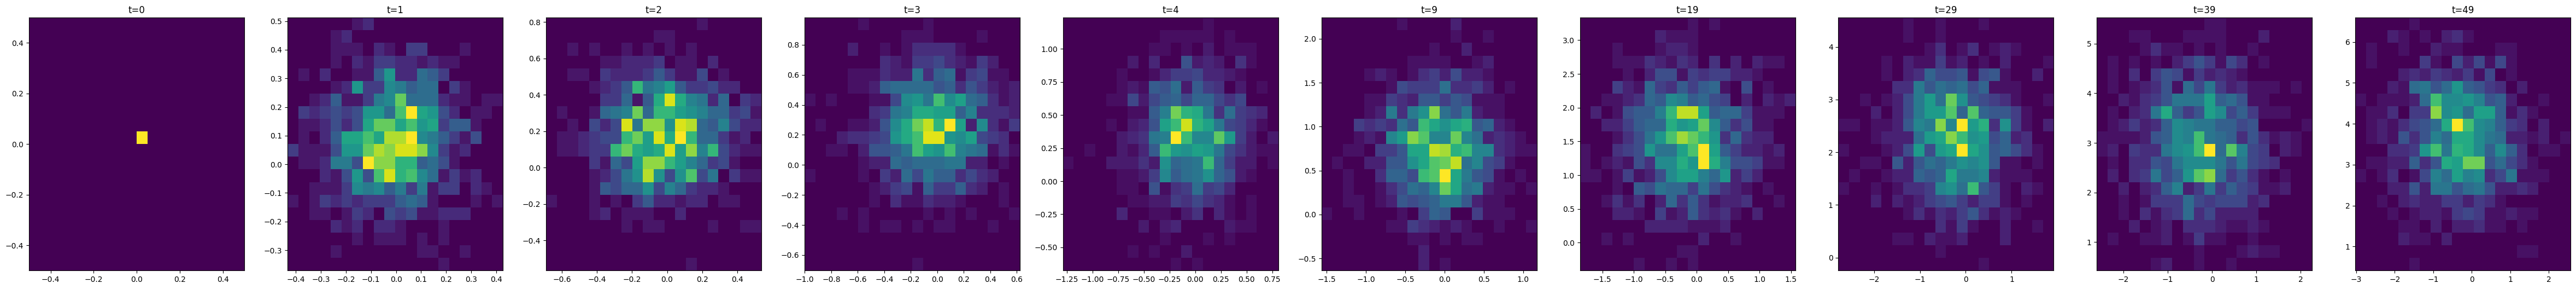

In [127]:
t_view = [1,2,3,4,5,10,20,30,40,50]
fig, ax =subplots(1, length(t_view), 6)
for i in eachindex(t_view)
    ax[i].hist2d(x_sim[1,:,t_view[i]], x_sim[2,:,t_view[i]], bins=20)
    ax[i].set_title("t=$(t_view[i]-1)")
end

In [146]:
t_sample = [1,5,10]

3-element Vector{Int64}:
  1
  5
 10

# Single thread

In [147]:
data = collect_data(zeros(d), x_sim[:,:,t_sample .+ 1], fill(1.0, nsamples, length(t_sample)), t_sample)

Data([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], DiffusionEvolution.Sample[DiffusionEvolution.Sample([0.06482242289453978 0.1520071071851909 … -0.0028762161231875227 0.11179961438127424; 0.0334274445895472 -0.15269040464864203 … 0.1926449684678228 0.05441412019214854; … ; -0.12094055684383004 -0.252320788095259 … -0.05902279442290596 -0.1539365569267344; -0.3026845919402082 0.13332593447565408 … -0.20394641449586104 -0.25022353139107206], [0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001  …  0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001]), DiffusionEvolution.Sample([0.4129650738973735 0.26075876955221966 … 0.1123233105748965 -0.4394462889062092; -0.018782746150647664 0.0630919007806306 … 0.9357233886715607 0.08627873643889428; … ; -0.1821799645498211 -0.6312377988002669 … -0.41482417312874154 -0.6745803877141322; -0.464461499253631 0.15193291293420005 … -0.6543790061084441 -0.7180867226934758], [0.001, 0.001, 0.001, 0.001, 0.001, 0.001

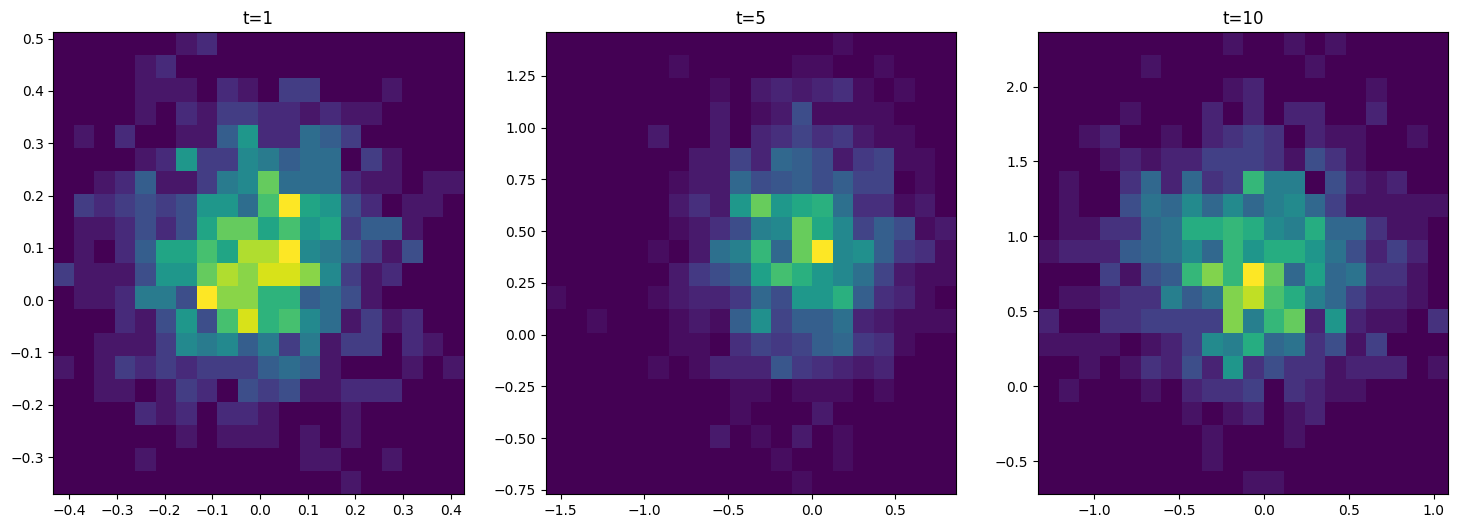

In [148]:
fig, ax =subplots(1, length(data.round), 6)
for i in eachindex(data.round)
    ax[i].hist2d(data.round[i].x[1,:], data.round[i].x[2,:], weights=data.round[i].w, bins=20)
    ax[i].set_title("t=$(data.time[i])")
end

In [173]:
lambda = 0.01
prior_J = 0.0
prior_theta = 0.0
prior_gamma = 0.0
epsilon = 1e-6
eps_conv = 1e-7

1.0e-7

In [174]:
opt_results_gamma = learn_gamma_nlopt(data; initialize=length(t_sample), xtol_abs=eps_conv, xtol_rel=eps_conv, ftol_abs=eps_conv,
    ftol_rel=eps_conv, lambda=lambda, prior_J=prior_J, prior_theta=prior_theta, prior_gamma=prior_gamma, epsilon=epsilon)

Initializing parameters with covariance.


(minf = 7.751576025881379, minx = [0.1643066192753933, -0.029459472465811407, -0.06215815704699909, 0.006100470065164967, -0.05957118166885801, -0.035831338363249136, -0.007240524149932122, 0.08757789336478689, -0.0132107338629247, -0.038717874458337374  …  6.012013244704078, -3.858814119762769, 11.617592436340857, -1.4899551044320203, -4.475547637026363, 4.571394438824684, -0.865622246647835, -1.078618660777232, -2.9033003084155196, 70.14955763053386], status = :FTOL_REACHED, nevals = 1100, x_start = [2.4012770655206723, -0.8678050106105635, -2.6675072230638306, -0.4118949101777477, 0.4304176861770646, -0.8578500729232444, 0.3817464265949383, 1.0546658103834707, 1.2416937679180586, -0.42178807314089195  …  0.8130657193876479, 0.6353772780639442, 1.9608346826333265, -0.9614189158393517, -0.8637902321048612, 0.5008258821950543, 0.5799522898829392, -0.8958028851129571, -0.8476754519454663, 10.0])

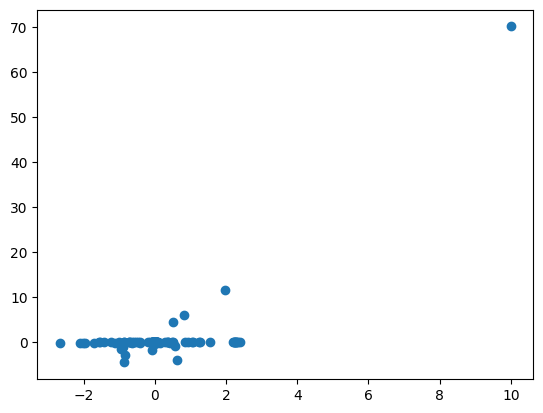

PyObject <matplotlib.collections.PathCollection object at 0x75acc4061d50>

In [175]:
scatter(opt_results_gamma.x_start, opt_results_gamma.minx)

In [176]:
opt_results_gamma.minx[end]|>inv

0.0142552573925959

In [177]:
g = zeros(de.npars_gamma(d))
de.optim_wrapper_gamma(opt_results_gamma.x_start, g, data, lambda, prior_J, prior_theta, prior_gamma, epsilon)

803.4675145460793

In [178]:
g

111-element Vector{Float64}:
   10.98311302388142
  -44.2948540216001
  -36.39326522826004
  -96.17920830559358
   43.576899375100815
   37.60062062107311
  -28.233001735785358
  -25.550409944493914
   41.928826123228674
   34.730012816979816
   -0.6795881066684804
   15.270367511851976
   -1.2979037861588516
    ⋮
   39.5193983738164
 -157.30670541763078
   86.67170575723398
  308.4947064919395
  222.0774132911189
 -269.766041365665
  -56.62647895315648
 -181.05409806508084
   36.381231239702245
 -430.1577262562157
 -278.48455249515376
   83.55821136323735

In [168]:
de.log_likelihood_gamma(opt_results_gamma.x_start, data, lambda, prior_J, prior_theta, prior_gamma, epsilon)

1133.1482009191627

In [ ]:
opt_results = learn_nlopt(data; initialize=length(t_sample), xtol_abs=eps_conv, xtol_rel=eps_conv, ftol_abs=eps_conv,
    ftol_rel=eps_conv, prior_x=prior_x, lambda=lambda, epsilon=epsilon, gamma=γ)

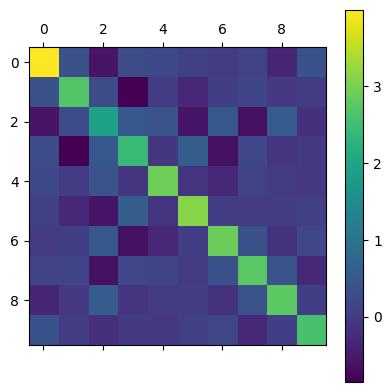

PyObject <matplotlib.colorbar.Colorbar object at 0x75acc40d68c0>

In [179]:
J_inf = de.compute_J(opt_results_gamma.minx, d, epsilon)*opt_results_gamma.minx[end]
matshow(J_inf)
colorbar()

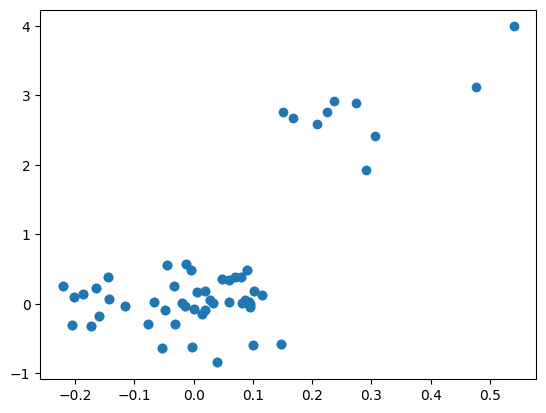

PyObject <matplotlib.collections.PathCollection object at 0x75acbbfa88b0>

In [180]:
scatter(J, J_inf)

In [181]:
teacher_ene = compute_energy(data.round[end].x, J, θ)
student_ene = compute_energy(data.round[end].x, opt_results_gamma.minx, epsilon);

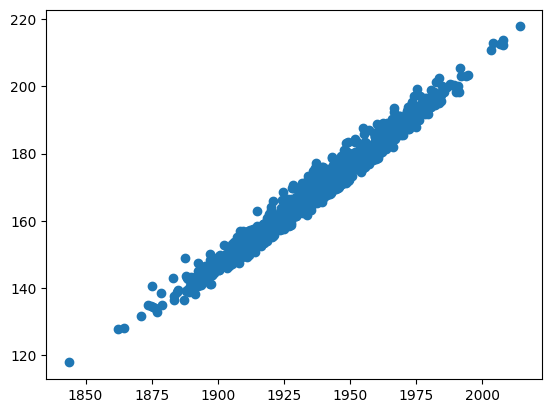

PyObject <matplotlib.collections.PathCollection object at 0x75acbbe195d0>

In [182]:
scatter(teacher_ene, student_ene)

In [ ]:
fig, ax = subplots(1,3,6)
ax[1].scatter(opt_results_gamma.x_start, opt_results_gamma.minx)
ax[2].scatter(opt_results.x_start, opt_results.minx)
ax[3].scatter(opt_results_gamma.minx[1:end-1], opt_results.minx)

In [ ]:
gamma_grid = [0.005, 0.01, 0.02, 0.03, 0.05, 0.1, 0.2, 0.5, 1.0]
ll_val = zeros(length(gamma_grid))
for i in eachindex(gamma_grid)
    r = learn_nlopt(data; initialize=length(t_sample), xtol_abs=eps_conv, xtol_rel=eps_conv, ftol_abs=eps_conv,
        ftol_rel=eps_conv, prior_x=prior_x, epsilon=epsilon, γ=gamma_grid[i])
    ll_val[i] = r.minf
end

In [ ]:
plot(gamma_grid, ll_val, linestyle="dashed", marker="o")
yscale(:log)
xlabel("gamma")
ylabel("optimal log-likelihood");

In [ ]:
ll_val_gamma = [de.log_likelihood(opt_results_gamma.minx, data, γ, lambda, 0.0, 0.0, epsilon) for γ in gamma_grid]

In [ ]:
plot(gamma_grid, ll_val_gamma, linestyle="dashed", marker="o")
xlabel("gamma")
ylabel("log-likelihood")
yscale(:log)

In [ ]:
de.learn_nlopt_only_gamma(data, x0=opt_results.minx, xtol_abs=eps_conv, xtol_rel=eps_conv, ftol_abs=eps_conv,
    ftol_rel=eps_conv, lambda=lambda, prior_gamma=0.0, epsilon=epsilon) 

In [ ]:
r = de.maximize(data; initialize=0, γ=0.1, xtol_rel=eps_conv, 
    ftol_rel=eps_conv, xtol_abs=eps_conv, ftol_abs=eps_conv, maxtime=-1, maxeval=-1, lambda=lambda,
    prior_x=prior_x, prior_gamma=prior_gamma, epsilon=epsilon, iterations=20);

In [ ]:
r.minγ

In [ ]:
plot(r.ll_iter)
yscale(:log)

In [ ]:
b=de.form_batches(250,30)

In [ ]:
unique(vcat(b...)) |> extrema

# Multithread

In [ ]:
lambda = 0.01
prior_x = 0.01
prior_gamma = 0.01
epsilon = 1e-6
eps_conv = 1e-5

In [ ]:
d_val = [3,5,7,10]

In [ ]:
Threads.@threads for i in eachindex(d_val)
    f = "logs/opt_d$(d_val[i]).txt"
    data = collect_data(zeros(d_val[i]), x_sim[1:d_val[i],:,t_sample], fill(1.0, nsamples, length(t_sample)), t_sample)
    r = iterative_maximization(data; initialize=0, gamma=0.1, xtol_rel=eps_conv, 
        ftol_rel=eps_conv, xtol_abs=eps_conv, ftol_abs=eps_conv, lambda=lambda,
        prior_x=prior_x, prior_gamma=prior_gamma, epsilon=epsilon, iterations=5, logfile=f)
end

# Optim

In [153]:
lambda = 0.01
prior_J = 0.0
prior_theta = 0.0
prior_gamma = 0.0
epsilon = 1e-6
f_tol =1.0e-7
g_tol = 1.0e-2
x_tol = 1.0e-5

1.0e-5

In [183]:
opt_results_gamma_optim = learn_gamma_optim(data; initialize=length(t_sample), f_tol=f_tol, g_tol=g_tol, x_tol=x_tol,
    lambda=lambda, prior_J=prior_J, prior_theta=prior_theta, prior_gamma=prior_gamma, epsilon=epsilon)

Initializing parameters with covariance.


 * Status: success

 * Candidate solution
    Final objective value:     7.033280e+00

 * Found with
    Algorithm:     Fminbox with L-BFGS

 * Convergence measures
    |x - x'|               = 0.00e+00 ≤ 1.0e-05
    |x - x'|/|x'|          = 0.00e+00 ≤ 0.0e+00
    |f(x) - f(x')|         = 0.00e+00 ≤ 0.0e+00
    |f(x) - f(x')|/|f(x')| = 0.00e+00 ≤ 1.0e-07
    |g(x)|                 = 7.93e-03 ≤ 1.0e-02

 * Work counters
    Seconds run:   3  (vs limit Inf)
    Iterations:    56
    f(x) calls:    3085
    ∇f(x) calls:   3085


In [184]:
opt_results_gamma_optim.initial_x

111-element Vector{Float64}:
  2.4012770655206723
  2.077424749374753
 -0.07262027869715369
 -0.4134544097410137
  2.0143516554426992
  0.20286406204421026
 -0.31390662103986966
  0.8983490821342853
 -0.02328875980101989
 -0.41534444822456196
  0.02191278112672941
  2.2799995372048123
 -0.26206723875057686
  ⋮
  2.195221272511978
 -0.07949448488753931
  0.8130657193876479
  0.6353772780639442
  1.9608346826333265
 -0.9614189158393517
 -0.8637902321048612
  0.5008258821950543
  0.5799522898829392
 -0.8958028851129571
 -0.8476754519454663
 10.0

In [185]:
opt_results_gamma_optim.minimizer

111-element Vector{Float64}:
   0.036219933702923326
  -0.027062115955034754
   0.060375455051437
  -0.023938277045824675
  -0.043435186660959815
  -0.015904354614133368
  -0.030801774442306622
  -0.0005956576682238872
  -0.05351256201392441
  -0.012790905872927834
  -0.03127025281190352
   0.0320270816237822
   0.021717142598665924
   ⋮
  -0.014527307633984467
   6.123869681382915
  22.87366735377001
   5.017832214239596
  29.82464498177061
 -18.49734179897947
  -7.140659609678453
  10.527944022703418
   8.239651302126743
  -5.537086440952591
  -7.10467533581736
  94.45117956909345

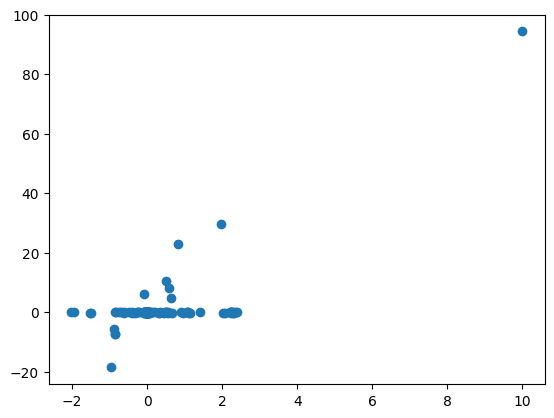

PyObject <matplotlib.collections.PathCollection object at 0x75acdc045c30>

In [186]:
scatter(opt_results_gamma_optim.initial_x, opt_results_gamma_optim.minimizer)

In [187]:
opt_results_gamma_optim.minimizer[end] |> inv

0.010587480268242435

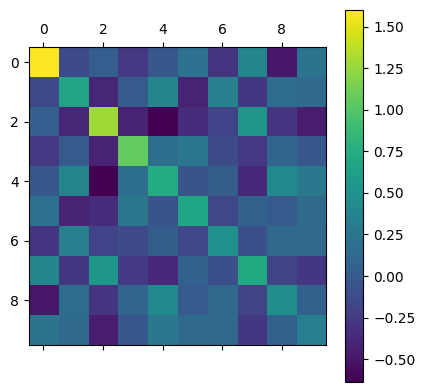

PyObject <matplotlib.colorbar.Colorbar object at 0x75acc7fabd90>

In [188]:
J_inf = de.compute_J(opt_results_gamma_optim.minimizer, d, epsilon)*opt_results_gamma_optim.minimizer[end]
matshow(J_inf)
colorbar()

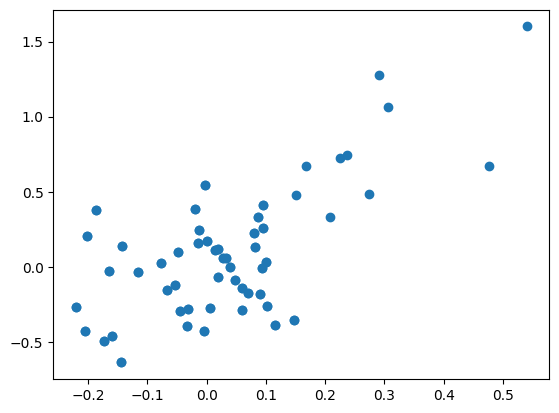

PyObject <matplotlib.collections.PathCollection object at 0x75acbbdc91b0>

In [189]:
scatter(J, J_inf)

In [192]:
teacher_ene = compute_energy(data.round[end].x, J, θ)
student_ene = compute_energy(data.round[end].x, opt_results_gamma_optim.minimizer, epsilon);

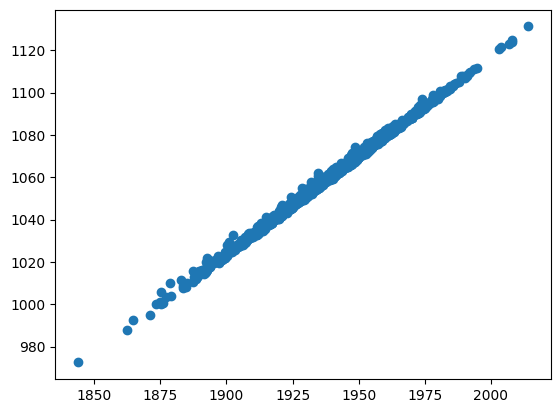

PyObject <matplotlib.collections.PathCollection object at 0x75acbb9b56f0>

In [193]:
scatter(teacher_ene, student_ene)